In [5]:
import pandas as pd

df=pd.read_csv("Sample - Superstore.csv", on_bad_lines="skip")
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [6]:
df.shape

(9994, 21)

In [7]:
print(df.isnull().sum())



Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [9]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [10]:
top_products = df.groupby("Product Name")["Sales"].sum() \
                .sort_values(ascending=False).head(5)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

print(monthly_sales)

Order Date
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


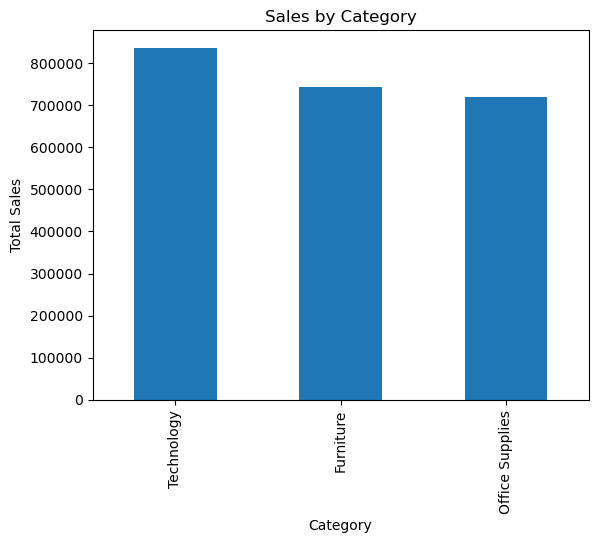

In [12]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

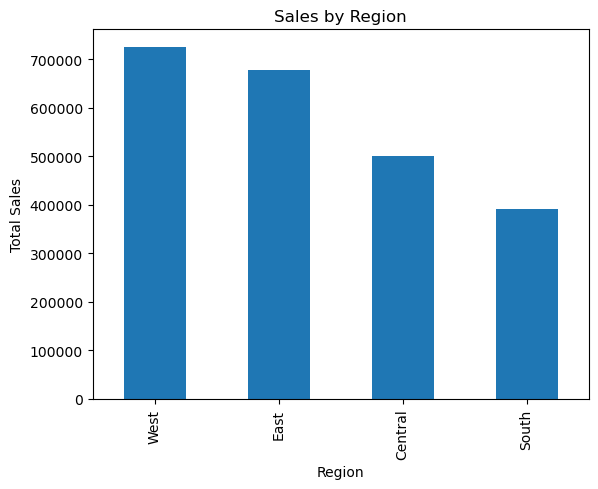

In [13]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

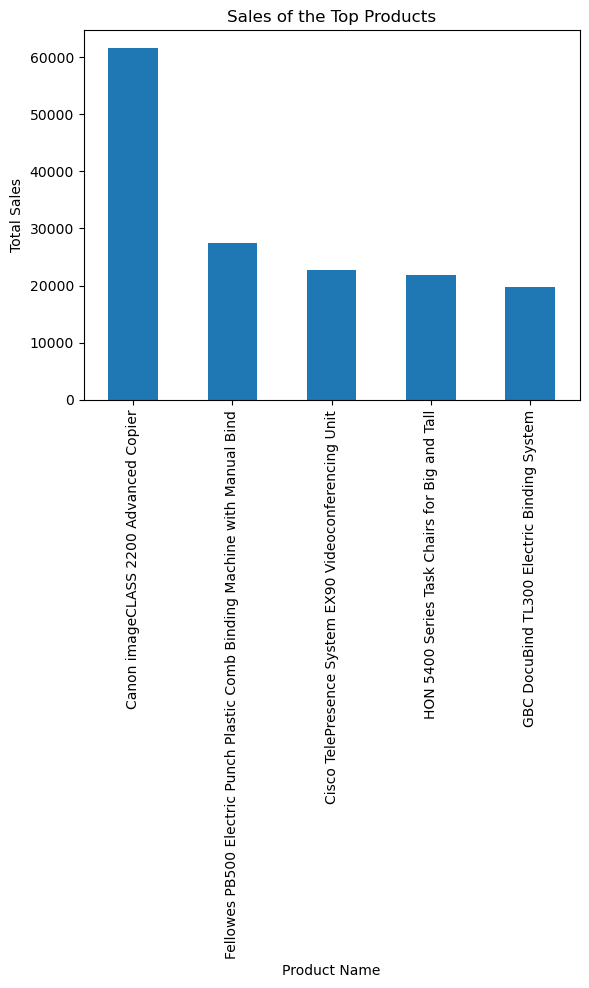

In [14]:
top_products.plot(kind="bar")
plt.title("Sales of the Top Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


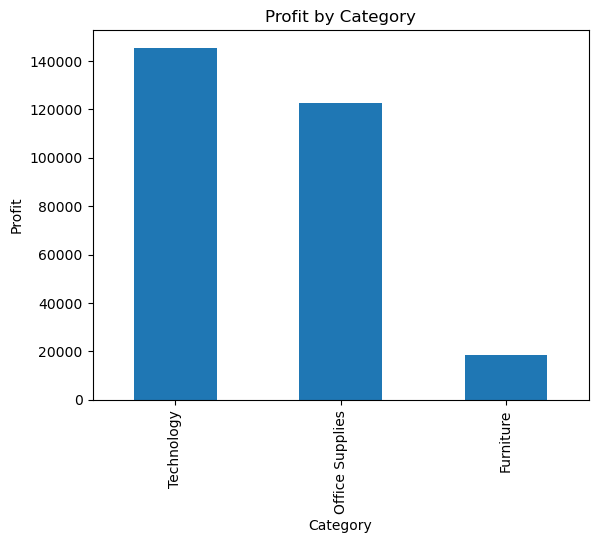

In [15]:
Category_Profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(Category_Profit)

import matplotlib.pyplot as plt

Category_Profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [16]:
import os
print(os.getcwd())

/drive/notebooks


In [17]:
import sqlite3
import pandas as pd

# Load CSV
df = pd.read_csv("Sample - Superstore.csv")

# Create database in memory (temporary, safe)
conn = sqlite3.connect(":memory:")

# Write CSV to SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)

# Test query
query = "SELECT Category, SUM(Sales) AS total_sales FROM sales GROUP BY Category"
result = pd.read_sql(query, conn)
print(result)

conn.close()

          Category  total_sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


In [18]:
# Example 1: Total sales per region
conn = sqlite3.connect(":memory:")

# Write CSV to SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)
query = """
SELECT region, SUM(Sales) AS total_sales
FROM sales 
GROUP BY region
ORDER BY total_sales DESC
"""
df_sales_region = pd.read_sql_query(query, conn)
print(df_sales_region)

# Example 2: Top 5 products by sales
query2 = """
SELECT "Product Name", SUM(Sales) AS total_sales
FROM sales
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 5
"""
df_top_products = pd.read_sql_query(query2, conn)
print(df_top_products)

    Region  total_sales
0     West  725457.8245
1     East  678781.2400
2  Central  501239.8908
3    South  391721.9050
                                        Product Name  total_sales
0              Canon imageCLASS 2200 Advanced Copier    61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...    27453.384
2  Cisco TelePresence System EX90 Videoconferenci...    22638.480
3       HON 5400 Series Task Chairs for Big and Tall    21870.576
4         GBC DocuBind TL300 Electric Binding System    19823.479


In [19]:
conn = sqlite3.connect(":memory:")

# Write CSV to SQL table
df.to_sql("sales", conn, if_exists="replace", index=False)

query = """
SELECT category, AVG(profit) AS avg_profit
FROM sales
GROUP BY category
ORDER BY AVG(Profit) DESC;
"""
df_Avg_Profit = pd.read_sql_query(query, conn)
print(df_Avg_Profit)

          Category  avg_profit
0       Technology   78.752002
1  Office Supplies   20.327050
2        Furniture    8.699327


In [20]:
#Top 5 Customers by Profit": 

query5= """
SELECT "Customer Name", SUM(profit) AS total_profit
FROM sales
GROUP BY "Customer Name"
ORDER BY total_profit DESC
LIMIT 5;
"""
df_Cust_by_Profit = pd.read_sql_query(query5, conn)
print(df_Cust_by_Profit)


   Customer Name  total_profit
0   Tamara Chand     8981.3239
1   Raymond Buch     6976.0959
2   Sanjit Chand     5757.4119
3   Hunter Lopez     5622.4292
4  Adrian Barton     5444.8055


In [21]:
#Orders with Discount > 20%": 

query="""
SELECT "Order Id", "Product Name", Discount, Sales
FROM sales
WHERE Discount > 0.2
ORDER BY Discount DESC
LIMIT 5;
"""
df_disc_20 = pd.read_sql_query(query, conn)
print(df_disc_20)


         Order ID                                       Product Name  \
0  US-2015-118983  Holmes Replacement Filter for HEPA Air Cleaner...   
1  US-2015-118983   Storex DuraTech Recycled Plastic Frosted Binders   
2  US-2017-118038                                    Economy Binders   
3  CA-2016-158568      Avery Hidden Tab Dividers for Binding Systems   
4  CA-2014-139892       Kensington 7 Outlet MasterPiece Power Center   

   Discount    Sales  
0       0.8   68.810  
1       0.8    2.544  
2       0.8    1.248  
3       0.8    1.788  
4       0.8  177.980  


In [22]:
import pandas as pd

# Load CSV
df = pd.read_csv("Sample - Superstore.csv")

# Rename columns
df.rename(columns={
    'Order ID': 'OrderID',
    'Order Date': 'OrderDate',
    'Ship Date': 'ShipDate',
    'Customer Name': 'CustomerName',
    'Product Name': 'ProductName',
    'Sub-Category': 'SubCategory'
}, inplace=True)

# Save cleaned CSV
df.to_csv("Superstore_cleaned.csv", index=False)

In [23]:
import os

# Show current working directory
print(os.getcwd())

/drive/notebooks


In [24]:
df.to_csv(r"C:\Users\Nafisa\Documents\Superstore_cleaned.csv", index=False)

In [25]:
import pandas as pd

# Example: load CSV
df = pd.read_csv("Superstore_cleaned.csv")

# Calculate Profit Margin as a new column
df['ProfitMargin'] = (df['Profit'] / df['Sales']) * 100

# Optional: round to 2 decimal places
df['ProfitMargin'] = df['ProfitMargin'].round(2)

# Check the first rows
print(df[['ProductName', 'Sales', 'Profit', 'ProfitMargin']].head())

                                         ProductName     Sales    Profit  \
0                  Bush Somerset Collection Bookcase  261.9600   41.9136   
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400  219.5820   
2  Self-Adhesive Address Labels for Typewriters b...   14.6200    6.8714   
3      Bretford CR4500 Series Slim Rectangular Table  957.5775 -383.0310   
4                     Eldon Fold 'N Roll Cart System   22.3680    2.5164   

   ProfitMargin  
0         16.00  
1         30.00  
2         47.00  
3        -40.00  
4         11.25  


In [26]:
high_margin = df[df['ProfitMargin'] > 20]  # Profit margin > 20%
print(high_margin[['ProductName', 'ProfitMargin']])

                                            ProductName  ProfitMargin
1     Hon Deluxe Fabric Upholstered Stacking Chairs,...         30.00
2     Self-Adhesive Address Labels for Typewriters b...         47.00
5     Eldon Expressions Wood and Plastic Desk Access...         29.00
6                                            Newell 322         27.00
8     DXL Angle-View Binders with Locking Rings by S...         31.25
...                                                 ...           ...
9986  Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...         42.00
9987  Logitech G430 Surround Sound Gaming Headset wi...         36.00
9988                    Panasonic KX - TS880B Telephone         27.00
9992  It's Hot Message Books with Stickers, 2 3/4" x 5"         45.00
9993  Acco 7-Outlet Masterpiece Power Center, Wihtou...         30.00

[5896 rows x 2 columns]


In [27]:
top5_margin = df.sort_values(by='ProfitMargin', ascending=False).head(5)

print(top5_margin[['ProductName', 'Sales', 'Profit', 'ProfitMargin']])


                                            ProductName   Sales   Profit  \
2187                                    Staple envelope   70.08   35.040   
534                      Presstex Flexible Ring Binders   22.75   11.375   
8523  Adams Telephone Message Book w/Frequently-Call...   55.86   27.930   
6768                Performers Binder/Pad Holder, Black  196.21   98.105   
9652  GE 48" Fluorescent Tube, Cool White Energy Sav...  595.38  297.690   

      ProfitMargin  
2187          50.0  
534           50.0  
8523          50.0  
6768          50.0  
9652          50.0  


In [28]:
# Average Profit Margin per category
avg_margin = df.groupby('Category')['ProfitMargin'].mean().sort_values(ascending=False).head(5)
print(avg_margin)

Category
Technology         15.613812
Office Supplies    13.803032
Furniture           3.878326
Name: ProfitMargin, dtype: float64


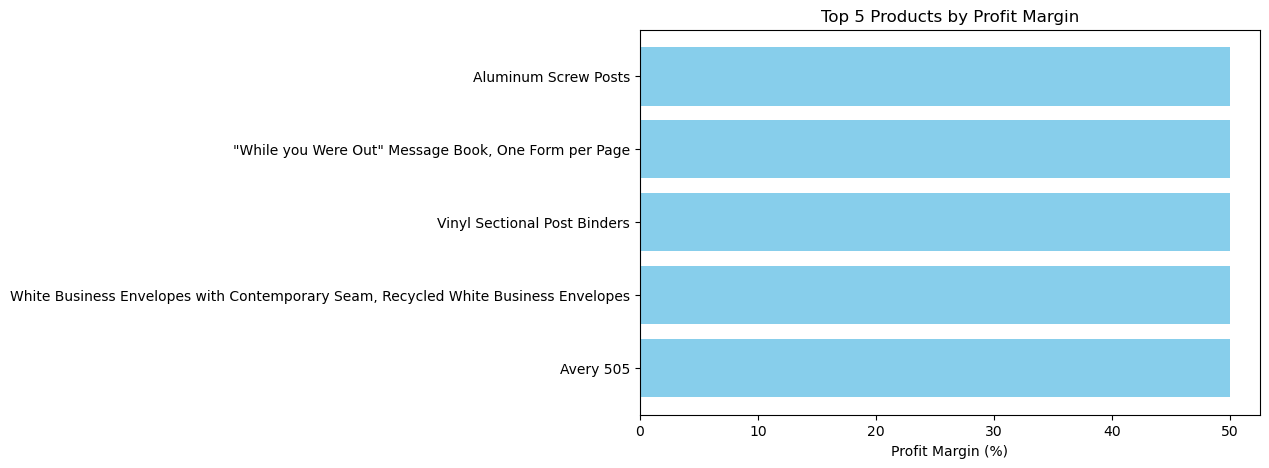

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your cleaned dataset
df = pd.read_csv("Superstore_cleaned.csv")

# Calculate Profit Margin
df['ProfitMargin'] = (df['Profit'] / df['Sales']) * 100

# Top 5 products by Profit Margin
top5_margin = df.sort_values(by='ProfitMargin', ascending=False).head(5)

# Plot using Matplotlib
plt.figure(figsize=(8,5))
plt.barh(top5_margin['ProductName'], top5_margin['ProfitMargin'], color='skyblue')
plt.xlabel('Profit Margin (%)')
plt.title('Top 5 Products by Profit Margin')
plt.gca().invert_yaxis()  # Highest at top
plt.show()

In [30]:
df.to_csv(r"C:\Users\Nafisa\Documents\Superstore_cleaned.csv", index=False)

print(df.to_csv)

<bound method NDFrame.to_csv of       Row ID         OrderID   OrderDate    ShipDate       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID      CustomerName    Segment        Country             City  \
0       CG-12520      

In [31]:
df.to_csv(r"C:\Nafisa\Documents\Superstore_cleaned.csv", index=False)

print(df.to_csv)

<bound method NDFrame.to_csv of       Row ID         OrderID   OrderDate    ShipDate       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID      CustomerName    Segment        Country             City  \
0       CG-12520      

In [35]:
df.to_csv(r"C:\Users\bhomn\Downloads\Superstore_cleaned.csv", index=False)

print(df.to_csv)

<bound method NDFrame.to_csv of       Row ID         OrderID   OrderDate    ShipDate       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID      CustomerName    Segment        Country             City  \
0       CG-12520      